In [25]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from transformers import ViTForImageClassification

In [26]:
!pip install transformers torch torchvision pillow matplotlib requests

In [27]:
import torch
import requests
from PIL import Image
import matplotlib.pyplot as plt

from transformers import ViTImageProcessor
from transformers import ViTForImageClassification

In [28]:
import torch

print(torch.__version__)

2.13.0+cpu


In [29]:
processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224"
)

print("Processor Loaded")

Processor Loaded


In [30]:
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224"
)

print("Model Loaded")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model Loaded


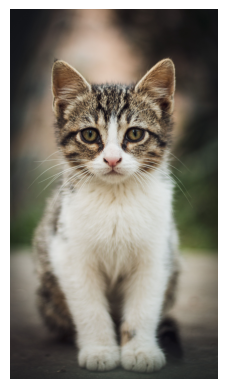

In [31]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("cat.jpeg")

plt.imshow(image)
plt.axis("off")
plt.show()

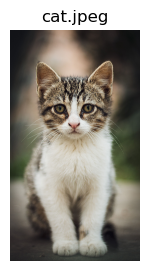

Image: cat.jpeg
Predicted Class: Egyptian cat
Confidence Score: 52.4 %
---------------------------


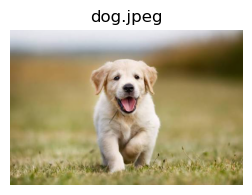

Image: dog.jpeg
Predicted Class: Labrador retriever
Confidence Score: 96.68 %
---------------------------


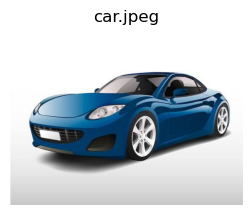

Image: car.jpeg
Predicted Class: sports car, sport car
Confidence Score: 92.17 %
---------------------------


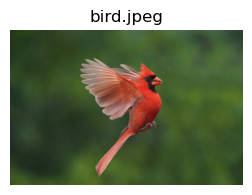

Image: bird.jpeg
Predicted Class: house finch, linnet, Carpodacus mexicanus
Confidence Score: 24.97 %
---------------------------


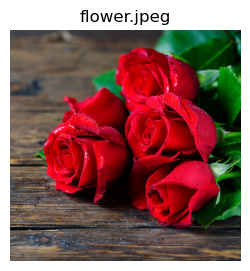

Image: flower.jpeg
Predicted Class: vase
Confidence Score: 36.97 %
---------------------------


In [32]:
from PIL import Image
import torch
import matplotlib.pyplot as plt

# List of image names
image_files = [
    "cat.jpeg",
    "dog.jpeg",
    "car.jpeg",
    "bird.jpeg",
    "flower.jpeg"
]

# Predict each image
for img_name in image_files:
    
    # Load image
    image = Image.open(img_name).convert("RGB")
    
    # Display image
    plt.figure(figsize=(3,3))
    plt.imshow(image)
    plt.axis("off")
    plt.title(img_name)
    plt.show()
    
    # Process image
    inputs = processor(images=image, return_tensors="pt")
    
    # Prediction
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Get class and confidence
    predicted_class = outputs.logits.argmax(-1).item()
    label = model.config.id2label[predicted_class]
    
    confidence = torch.nn.functional.softmax(
        outputs.logits, dim=1
    )[0][predicted_class].item()
    
    print("Image:", img_name)
    print("Predicted Class:", label)
    print("Confidence Score:", round(confidence*100,2), "%")
    print("---------------------------")